### **CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS**

Nesta célula, importamos todas as bibliotecas necessárias para a análise e construção dos modelos de Machine Learning. Cada biblioteca tem uma função específica:

*   **`pandas` (pd)**: Utilizada para manipulação e análise de dados, especialmente DataFrames.
*   **`numpy` (np)**: Fundamental para operações numéricas e matemáticas de alto desempenho.
*   **`matplotlib.pyplot` (plt)** e **`seaborn` (sns)**: Usadas para visualização de dados e criação de gráficos estatísticos.
*   **`sklearn.model_selection.train_test_split`**: Para dividir os dados em conjuntos de treinamento e teste.
*   **`sklearn.preprocessing.LabelEncoder`**: Para transformar variáveis categóricas em numéricas.
*   **`sklearn.ensemble.RandomForestClassifier`** e **`sklearn.naive_bayes.GaussianNB`**: Os algoritmos de Machine Learning que serão treinados.
*   **`sklearn.metrics`**: Contém funções para avaliar o desempenho dos modelos, como acurácia, precisão, recall, F1-Score e matriz de confusão.

O `sns.set(style="whitegrid")` configura um estilo padrão para os gráficos, tornando-os mais legíveis.

In [ ]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Configuração de estilo dos gráficos
sns.set(style="whitegrid")
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### **CÉLULA 2: CARREGAMENTO E VISUALIZAÇÃO DOS DADOS**

Esta célula é responsável por carregar o conjunto de dados (`baseMLJurandir.csv`) em um DataFrame do pandas. Após o carregamento, exibimos as primeiras 5 linhas (`df.head()`) para ter uma visão inicial dos dados e confirmamos suas dimensões (`df.shape`).

Um bloco `try-except` é usado para lidar com a situação em que o arquivo não é encontrado, fornecendo uma mensagem de erro útil para o usuário.

In [ ]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO E VISUALIZAÇÃO DOS DADOS
# ==============================================================================
try:
    df = pd.read_csv('baseMLJurandir.csv')
    print(f"Dataset carregado com sucesso! Dimensões: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("ERRO: O arquivo 'baseMLJurandir.csv' não foi encontrado.")
    print("Por favor, faça o upload do arquivo na aba de arquivos à esquerda ou verifique o caminho.")

Dataset carregado com sucesso! Dimensões: (1084215, 12)


,saltos,nÃºcleo,modulaÃ§Ã£o,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,consumo energia,peso,resultado
0,1,5,16.0,1050.0,1,3,-120.0,16.613496,2.000000e+11,0.0,0.0,1
1,3,5,4.0,2850.0,1,3,-120.0,12.349501,1.000000e+11,0.0,0.0,1
2,3,5,4.0,2850.0,1,10,-120.0,12.227845,4.000000e+11,0.0,0.0,1
3,3,5,4.0,2850.0,1,8,-120.0,12.253261,3.000000e+11,0.0,0.0,1
4,3,5,8.0,1550.0,1,9,-120.0,14.713263,5.000000e+11,0.0,0.0,1


## **CÉLULA 3: PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES**

Esta etapa é crucial para preparar os dados antes do treinamento dos modelos. Nesta versão, o processamento foi adaptado para suportar uma **classificação binária**, simplificando o problema para distinguir apenas entre circuitos aceitos e circuitos bloqueados.

### Correção de Colunas com Erro de Encoding
Foram identificados e corrigidos nomes de colunas com caracteres corrompidos (por exemplo: `Ãºcleo` → `núcleo`, além de variações relacionadas à modulação). Essa padronização garante que o código consiga manipular corretamente todas as variáveis do conjunto de dados.

### Definição da Variável Target (`resultado`)
Os diferentes tipos de bloqueio foram **agrupados em uma única classe**, transformando o problema em binário. A variável `resultado` passou a representar apenas a aceitação ou bloqueio do circuito, conforme:

- **0 → Bloqueio (qualquer motivo)**  
- **1 → Aceito**

Essa simplificação permite que o modelo foque exclusivamente em prever se uma requisição será atendida ou não, sem diferenciar a causa específica do bloqueio, tornando o problema mais direto e reduzindo a complexidade da classificação.

### Engenharia de Features (`slots_usados`)
Foi criada uma nova feature chamada **`slots_usados`**, calculada como:

`slots_usados = ultimo_slot - primeiro_slot`

Essa variável representa a largura espectral utilizada pela requisição. As colunas originais **`primeiro_slot`** e **`ultimo_slot`** foram mantidas, pois a posição do espectro também pode conter informações relevantes para o modelo.

### Remoção de Colunas Específicas
Foram removidas as colunas relacionadas a peso e consumo de energia. A exclusão considerou possíveis variações nos nomes das colunas, garantindo a limpeza completa, já que essas variáveis não serão utilizadas na predição.

### Codificação da Modulação
A variável categórica **`modulação`** foi convertida para valores numéricos utilizando **LabelEncoder**, permitindo que os algoritmos de Machine Learning processem corretamente essa informação textual.

### Validação Final
Ao final do pré-processamento, a estrutura do **DataFrame** é exibida para confirmar que:

- a coluna **`resultado`** está no formato binário (0 e 1)  
- as colunas de peso e consumo foram removidas  
- as novas features foram criadas corretamente  
- os dados estão prontos para o treinamento dos modelos


Colunas do DataFrame antes do pré-processamento: ['saltos', 'nÃºcleo', 'modulaÃ§Ã£o', 'comprimento', 'primeiro slot', 'ultimo slot', 'XT', 'OSNR', 'banda', 'consumo energia', 'peso', 'resultado']
Coluna 'nÃºcleo' renomeada para 'núcleo'.
Coluna 'modulaÃ§Ã£o' renomeada para 'modulação'.
Variável 'resultado' transformada para BINÁRIA: 1=Aceito, 0=Bloqueado (QoT/XT).
Distribuição das classes em 'resultado':
resultado
0    374983
1    709232
Name: count, dtype: int64


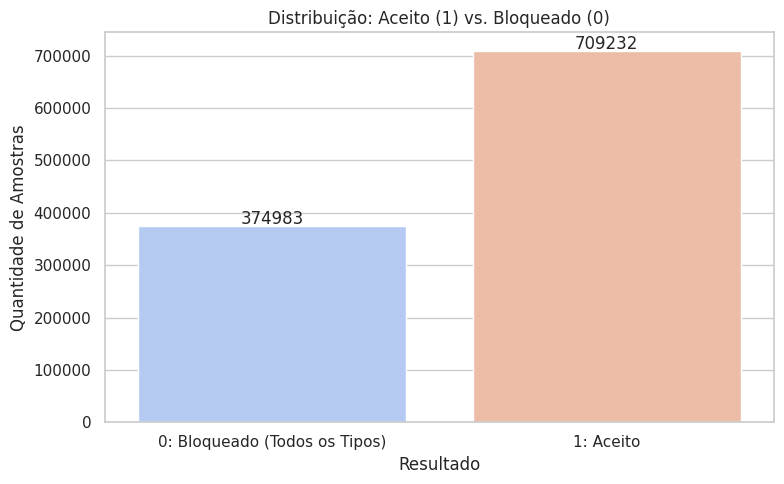

Sucesso! Colunas removidas: ['consumo energia', 'peso']

--- Estrutura Final do Dataset ---


,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,resultado,slots_usados
0,1,5,16.0,1050.0,1,3,-120.0,16.613496,2.000000e+11,1,3
1,3,5,4.0,2850.0,1,3,-120.0,12.349501,1.000000e+11,1,3
2,3,5,4.0,2850.0,1,10,-120.0,12.227845,4.000000e+11,1,10
3,3,5,4.0,2850.0,1,8,-120.0,12.253261,3.000000e+11,1,8
4,3,5,8.0,1550.0,1,9,-120.0,14.713263,5.000000e+11,1,9


Colunas finais: ['saltos', 'núcleo', 'modulação', 'comprimento', 'primeiro slot', 'ultimo slot', 'XT', 'OSNR', 'banda', 'resultado', 'slots_usados']


In [ ]:
# ==============================================================================
# CÉLULA 3: PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar avisos de depreciação e avisos de usuário para limpar a saída
warnings.filterwarnings('ignore')

print("Colunas do DataFrame antes do pré-processamento:", df.columns.tolist())

# --- 1. Correção de Colunas com Erro de Encoding ---
def corrigir_coluna(df, prefixo_esperado, sufixos_erro, nome_correto):
    found_col = None
    for col in df.columns:
        if prefixo_esperado in col.lower():
            for sufixo in sufixos_erro:
                if sufixo in col:
                    found_col = col
                    break
            if found_col:
                break

    if found_col and found_col != nome_correto:
        df.rename(columns={found_col: nome_correto}, inplace=True)
        print(f"Coluna '{found_col}' renomeada para '{nome_correto}'.")
    elif found_col and found_col == nome_correto:
        print(f"Coluna '{nome_correto}' já está com o nome correto.")

corrigir_coluna(df, 'n', ['Ãºcleo'], 'núcleo')
corrigir_coluna(df, 'modula', ['Ã§Ã£o', 'ção'], 'modulação')
# --- Fim da Correção ---

# 2. Tratamento da Variável Target (TRANSFORMAÇÃO BINÁRIA)
# Regra: Se for 1 (Aceito) mantem 1. Todo o resto (2,3,4,5) vira 0.
df['resultado'] = df['resultado'].apply(lambda x: 1 if x == 1 else 0)

print("Variável 'resultado' transformada para BINÁRIA: 1=Aceito, 0=Bloqueado (QoT/XT).")

# Imprimir contagem textual
print("Distribuição das classes em 'resultado':")
contagem = df['resultado'].value_counts().sort_index()
print(contagem)

# --- Visualização Gráfica da Distribuição (Ajustada para Binário) ---
plt.figure(figsize=(8, 5))

# Correção do aviso do Seaborn: Adicionado hue='resultado' e legend=False
ax = sns.countplot(x='resultado', data=df, hue='resultado', palette='coolwarm', legend=False)

plt.title('Distribuição: Aceito (1) vs. Bloqueado (0)')
plt.xlabel('Resultado')
plt.ylabel('Quantidade de Amostras')

# Legenda explicativa atualizada para Binário
labels_map = {
    1: '1: Aceito',
    0: '0: Bloqueado (Todos os Tipos)'
}

# Ajusta os labels do eixo X
classes_presentes = sorted(df['resultado'].unique())
labels_finais = [labels_map.get(c, str(c)) for c in classes_presentes]

ax.set_xticks(range(len(classes_presentes)))
ax.set_xticklabels(labels_finais)

# Adicionar números em cima das barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()
# --- Fim do Gráfico ---

# 3. Criar feature "slots_usados"
df['slots_usados'] = df['ultimo slot'] - df['primeiro slot'] + 1

colunas_para_remover = []
for col in df.columns:
    c_lower = col.strip().lower()
    if c_lower == 'peso' or ('consumo' in c_lower and 'energia' in c_lower):
        colunas_para_remover.append(col)

if colunas_para_remover:
    df.drop(colunas_para_remover, axis=1, inplace=True)
    print(f"Sucesso! Colunas removidas: {colunas_para_remover}")
else:
    print("AVISO: Não encontrei as colunas 'peso' ou 'consumo de energia'.")

# 5. LabelEncoder para modulação
le = LabelEncoder()
if 'modulação' in df.columns and df['modulação'].dtype == 'object':
    df['modulação'] = le.fit_transform(df['modulação'])
    print("Classes de modulação codificadas:", list(le.classes_))

print("\n--- Estrutura Final do Dataset ---")
display(df.head())
print(f"Colunas finais: {df.columns.tolist()}")

## CÉLULA A: MATRIZ DE CORRELAÇÃO

Nesta etapa realizamos a análise de correlação entre as variáveis numéricas do conjunto de dados com o objetivo de identificar relações lineares, dependências fortes e possíveis problemas de multicolinearidade que possam impactar o desempenho dos modelos de Machine Learning. Inicialmente, é criada uma figura com tamanho ampliado para melhorar a visualização. Em seguida, a matriz de correlação é calculada utilizando `df.corr()`, que considera apenas colunas numéricas automaticamente. Posteriormente, essa matriz é representada visualmente por meio de um heatmap gerado com Seaborn, no qual cada célula exibe o valor da correlação entre duas variáveis, variando de -1 a 1. Valores próximos de 1 indicam forte correlação positiva, próximos de -1 indicam forte correlação negativa e próximos de 0 indicam pouca ou nenhuma relação linear. A anotação dos valores (`annot=True`) facilita a interpretação direta, enquanto o mapa de cores `coolwarm` destaca visualmente as intensidades das correlações. Essa análise auxilia na identificação de variáveis redundantes, possíveis features altamente relacionadas e oportunidades de seleção ou redução de dimensionalidade antes do treinamento dos modelos.


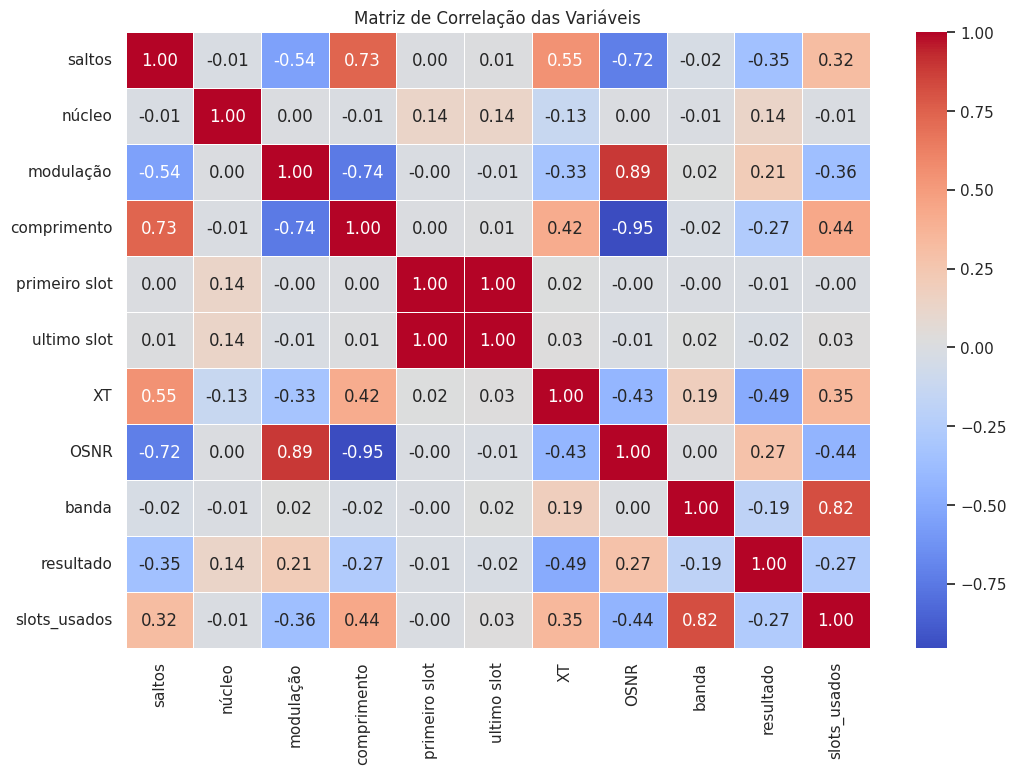

In [ ]:
# ==============================================================================
# NOVA CÉLULA A: MATRIZ DE CORRELAÇÃO
# ==============================================================================

plt.figure(figsize=(12, 8))
# Calculando a correlação apenas para colunas numéricas
correlation_matrix = df.corr()

# Criando o Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

## CÉLULA C: RELAÇÃO COMPRIMENTO × OSNR (Separado por Resultado)

Esta etapa tem como objetivo analisar visualmente a relação física entre o comprimento da fibra (`comprimento`) e a qualidade do sinal óptico (`OSNR`), separando os pontos de acordo com o tipo de resultado da requisição. Essa visualização ajuda a entender como a degradação do sinal ao longo da distância influencia a aceitação ou o bloqueio das conexões, além de identificar padrões, agrupamentos ou limites operacionais do sistema.

Para evitar sobrecarga gráfica e melhorar a legibilidade, é utilizada uma amostragem aleatória de até 5.000 registros quando o conjunto de dados é muito grande. Em seguida, é criado um gráfico de dispersão (`scatterplot`) com Seaborn, no qual cada ponto representa uma requisição: o eixo X corresponde ao comprimento da fibra (km) e o eixo Y ao OSNR (dB). As variáveis `hue` e `style` são definidas como `resultado`, permitindo diferenciar visualmente cada classe por cores e marcadores distintos.

Foi definida uma paleta de cores personalizada para facilitar a interpretação: a classe 1 (Aceito) é exibida em verde, enquanto as classes de bloqueio utilizam tons mais quentes ou escuros (laranja, vermelho, roxo e marrom), destacando visualmente os casos problemáticos. A legenda é ajustada para mapear explicitamente os códigos numéricos para seus respectivos significados.

Essa análise é útil para verificar, por exemplo, se comprimentos maiores tendem a reduzir o OSNR e aumentar a probabilidade de bloqueios, além de auxiliar na validação de hipóteses físicas do sistema e na identificação de possíveis features relevantes para os modelos de Machine Learning.


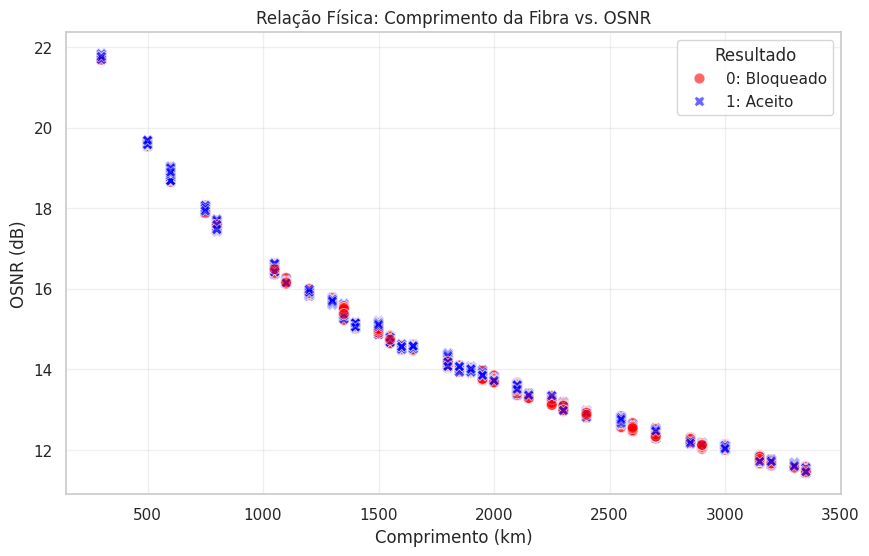

In [ ]:
# ==============================================================================
# NOVA CÉLULA C: RELAÇÃO COMPRIMENTO X OSNR (Binário: Bloqueado vs Aceito)
# ==============================================================================

# Vamos pegar uma amostra para o gráfico não ficar muito pesado
df_sample = df.sample(n=5000, random_state=42) if len(df) > 5000 else df

plt.figure(figsize=(10, 6))

# Definindo a paleta
palette_map = {0: 'red', 1: 'blue'}

# Criar o gráfico capturando o objeto 'ax' (eixo)
ax = sns.scatterplot(
    x='comprimento',
    y='OSNR',
    hue='resultado',
    style='resultado',
    data=df_sample,
    palette=palette_map,
    alpha=0.6,
    s=60 # Tamanho dos pontos
)

plt.title("Relação Física: Comprimento da Fibra vs. OSNR")
plt.xlabel("Comprimento (km)")
plt.ylabel("OSNR (dB)")

# --- CORREÇÃO DA LEGENDA ---
# 1. Pegamos os ícones (handles) e os textos (labels) atuais do gráfico
handles, labels = ax.get_legend_handles_labels()

# 2. Recriamos a legenda usando os MESMOS ícones, mas mudando o texto
# Assumindo que a ordem natural é 0 depois 1, definimos os novos textos:
novos_labels = ['0: Bloqueado', '1: Aceito']

plt.legend(handles=handles, labels=novos_labels, title="Resultado")

plt.grid(True, alpha=0.3)
plt.show()

### **CÉLULA 4: SEPARAÇÃO EM TREINO E TESTE**

Para avaliar corretamente o desempenho de um modelo de Machine Learning, é fundamental dividirmos o conjunto de dados em duas partes:

*   **Conjunto de Treino (Training Set)**: Usado para treinar o modelo, ou seja, para que ele aprenda os padrões nos dados.
*   **Conjunto de Teste (Test Set)**: Usado para avaliar o desempenho do modelo em dados *nunca antes vistos*. Isso nos ajuda a ter uma ideia de como o modelo se comportará em situações reais e a evitar o *overfitting* (quando o modelo memoriza os dados de treino, mas não generaliza bem para novos dados).

Aqui, utilizamos `train_test_split` para separar os dados em 70% para treino e 30% para teste. O parâmetro `random_state=42` garante que a divisão seja sempre a mesma cada vez que o código for executado, tornando os resultados reprodutíveis.

In [ ]:
# ==============================================================================
# CÉLULA 4: SEPARAÇÃO EM TREINO E TESTE
# ==============================================================================

# Definir X (features) e y (target)
# Removemos a coluna alvo 'resultado' das features (X)
X = df.drop('resultado', axis=1)

# A coluna alvo agora é 'resultado'
y = df['resultado']

# Separar: 70% Treino, 30% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

# Verificação opcional da distribuição no treino
print("\nDistribuição das classes no treino:")
print(y_train.value_counts(normalize=True).sort_index())

Tamanho do Treino: 758950 amostras
Tamanho do Teste: 325265 amostras

Distribuição das classes no treino:
resultado
0    0.345857
1    0.654143
Name: proportion, dtype: float64


=== DISTRIBUIÇÃO ORIGINAL ===
resultado
0    262488
1    496462
Name: count, dtype: int64

Classe 0: 262488
Classe 1: 496462

=== DISTRIBUIÇÃO BALANCEADA ===
resultado
0    262488
1    262488
Name: count, dtype: int64
Tamanho final do treino: 524976


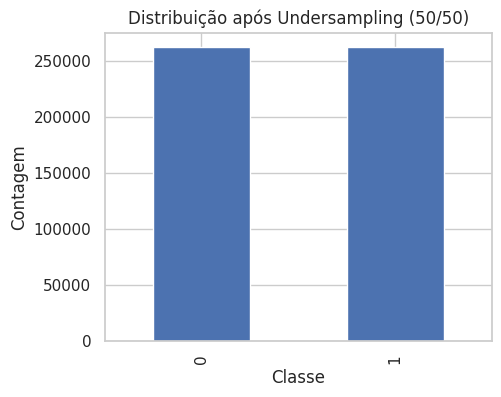

In [ ]:
# ==============================================================================
# CÉLULA 4.1: BALANCEAMENTO DO CONJUNTO DE TREINO (UNDERSAMPLING)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

print("=== DISTRIBUIÇÃO ORIGINAL ===")
print(y_train.value_counts().sort_index())

# ----------------------------------------------------------------------
# 1) Reconstruir dataframe temporário com X + y
# ----------------------------------------------------------------------
df_train = pd.concat([X_train, y_train], axis=1)

# ----------------------------------------------------------------------
# 2) Separar classes
# ----------------------------------------------------------------------
df_minority = df_train[df_train['resultado'] == 0]  # classe minoritária
df_majority = df_train[df_train['resultado'] == 1]  # classe majoritária

print(f"\nClasse 0: {len(df_minority)}")
print(f"Classe 1: {len(df_majority)}")

# ----------------------------------------------------------------------
# 3) Undersampling da majoritária
# ----------------------------------------------------------------------
df_majority_down = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# ----------------------------------------------------------------------
# 4) Combinar e embaralhar
# ----------------------------------------------------------------------
df_balanced = pd.concat([df_minority, df_majority_down]).sample(
    frac=1,
    random_state=42
)

# ----------------------------------------------------------------------
# 5) Separar novamente X e y
# ----------------------------------------------------------------------
X_train_bal = df_balanced.drop(columns='resultado')
y_train_bal = df_balanced['resultado']

print("\n=== DISTRIBUIÇÃO BALANCEADA ===")
print(y_train_bal.value_counts().sort_index())
print(f"Tamanho final do treino: {len(X_train_bal)}")

# ----------------------------------------------------------------------
# 6) Visualização simples (matplotlib puro)
# ----------------------------------------------------------------------
plt.figure(figsize=(5,4))
y_train_bal.value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição após Undersampling (50/50)")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


### **CÉLULA 5: TREINAMENTO DOS MODELOS**

Nesta célula, inicializamos e treinamos dois modelos de classificação diferentes:

1.  **Random Forest Classifier**: É um algoritmo de *ensemble learning* que constrói múltiplas árvores de decisão durante o treinamento e produz a classe que é a moda das classes de árvores individuais. É robusto, lida bem com dados não lineares e é menos propenso a overfitting que uma única árvore de decisão. O `n_estimators=100` indica que 100 árvores serão construídas.

2.  **Naive Bayes (GaussianNB)**: Um algoritmo de classificação baseado no Teorema de Bayes com a suposição de independência entre as *features*. O `GaussianNB` é usado quando as *features* seguem uma distribuição gaussiana (normal).

Ambos os modelos são treinados (`.fit()`) usando os dados de treino (`X_train`, `y_train`).

In [ ]:
# ==============================================================================
# CÉLULA 5: TREINAMENTO DOS MODELOS
# ==============================================================================

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)
print("Modelo Random Forest treinado.")

# 2. Naive Bayes (GaussianNB)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print("Modelo Naive Bayes treinado.")

Modelo Random Forest treinado.
Modelo Naive Bayes treinado.


### **CÉLULA 6: AVALIAÇÃO DOS MODELOS**

Após treinar os modelos, é fundamental avaliar seu desempenho. Uma função auxiliar `avaliar_modelo` foi criada para calcular e exibir métricas de avaliação comuns e uma matriz de confusão para cada modelo.

#### **Métricas de Avaliação:**

*   **Acurácia (Accuracy)**: A proporção de previsões corretas em relação ao total de previsões. É útil quando as classes são balanceadas.

*   **Precisão (Precision)**: Das previsões positivas do modelo, quantas estavam realmente corretas? É crucial quando o custo de um falso positivo é alto. Por exemplo, se nosso modelo prevê que um circuito será aceito (positivo), a precisão nos diz a chance de que ele *realmente* seja aceito.

*   **Recall (Sensibilidade)**: Dos casos realmente positivos, quantos o modelo conseguiu identificar corretamente? É fundamental quando o custo de um falso negativo é alto. Por exemplo, se um circuito *deveria* ser aceito (positivo real), o recall nos diz a chance de o modelo prevê-lo como aceito. No nosso contexto de aceitação/bloqueio de circuitos, um **alto Recall** para a classe `aceito=1` significa que o modelo é bom em identificar a maioria dos circuitos que *devem* ser aceitos, minimizando a chance de bloquear erroneamente um circuito válido (Falso Negativo).

*   **F1-Score**: É a média harmônica da Precisão e do Recall. É uma métrica útil quando se busca um equilíbrio entre Precisão e Recall, especialmente em datasets com classes desbalanceadas.

#### **Matriz de Confusão:**

A matriz de confusão é uma tabela que descreve o desempenho de um modelo de classificação em um conjunto de dados de teste para o qual os valores verdadeiros são conhecidos. Ela mostra o número de:

*   **Verdadeiros Positivos (VP)**: O modelo previu Positivo, e a realidade é Positivo.
*   **Verdadeiros Negativos (VN)**: O modelo previu Negativo, e a realidade é Negativo.
*   **Falsos Positivos (FP)**: O modelo previu Positivo, mas a realidade é Negativo (Erro Tipo I).
*   **Falsos Negativos (FN)**: O modelo previu Negativo, mas a realidade é Positivo (Erro Tipo II).

No nosso caso:
*   `0=Bloqueio`, `1=Aceito`
*   **VP**: O modelo previu 'Aceito', e o circuito foi 'Aceito'.
*   **VN**: O modelo previu 'Bloqueio', e o circuito foi 'Bloqueio'.
*   **FP**: O modelo previu 'Aceito', mas o circuito foi 'Bloqueio' (circuito bloqueado erroneamente).
*   **FN**: O modelo previu 'Bloqueio', mas o circuito foi 'Aceito' (circuito válido foi bloqueado).

O `classification_report` fornece um resumo detalhado dessas métricas para cada classe.

--- Resultados: Random Forest ---
Acurácia:  0.8009
Precision: 0.8163
Recall:    0.8009
F1-Score:  0.8045

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.68      0.82      0.74    112495
           1       0.89      0.79      0.84    212770

    accuracy                           0.80    325265
   macro avg       0.78      0.80      0.79    325265
weighted avg       0.82      0.80      0.80    325265



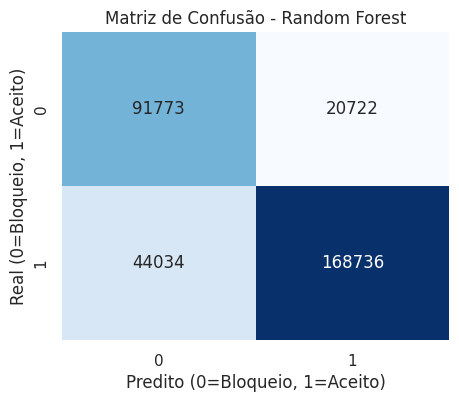

--- Resultados: Naive Bayes ---
Acurácia:  0.6652
Precision: 0.6417
Recall:    0.6652
F1-Score:  0.5796

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.59      0.11      0.18    112495
           1       0.67      0.96      0.79    212770

    accuracy                           0.67    325265
   macro avg       0.63      0.53      0.49    325265
weighted avg       0.64      0.67      0.58    325265



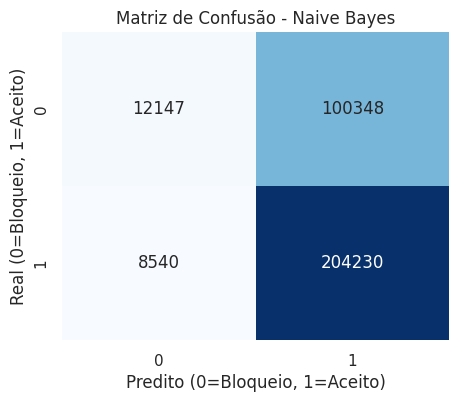

In [ ]:
# ==============================================================================
# CÉLULA 6: AVALIAÇÃO DOS MODELOS
# ==============================================================================

def avaliar_modelo(modelo, nome_modelo, X_test, y_test):
    """Função auxiliar para calcular métricas e plotar matriz de confusão"""
    y_pred = modelo.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    # Changed average='binary' to average='weighted' for robustness
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"--- Resultados: {nome_modelo} ---")
    print(f"Acurácia:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Predito (0=Bloqueio, 1=Aceito)')
    plt.ylabel('Real (0=Bloqueio, 1=Aceito)')
    plt.show()

    return [acc, prec, rec, f1]

# Avaliar Random Forest
metrics_rf = avaliar_modelo(rf_model, "Random Forest", X_test, y_test)

# Avaliar Naive Bayes
metrics_nb = avaliar_modelo(nb_model, "Naive Bayes", X_test, y_test)


### **CÉLULA 7: COMPARAÇÃO FINAL DOS MODELOS**

Nesta célula, consolidamos as métricas de avaliação de ambos os modelos (Random Forest e Naive Bayes) em um DataFrame para facilitar a comparação. Em seguida, visualizamos essas métricas usando um gráfico de barras comparativo.

Essa comparação visual é muito útil para entender rapidamente qual modelo se sai melhor em cada métrica e tomar uma decisão informada sobre qual modelo é mais adequado para a tarefa em questão, considerando os objetivos do negócio (por exemplo, se é mais importante minimizar falsos positivos ou falsos negativos).


--- Comparação Lado a Lado ---


,Métrica,Random Forest,Naive Bayes
0,Acurácia,0.800913,0.665233
1,Precision,0.816313,0.641706
2,Recall,0.800913,0.665233
3,F1-Score,0.804490,0.579552


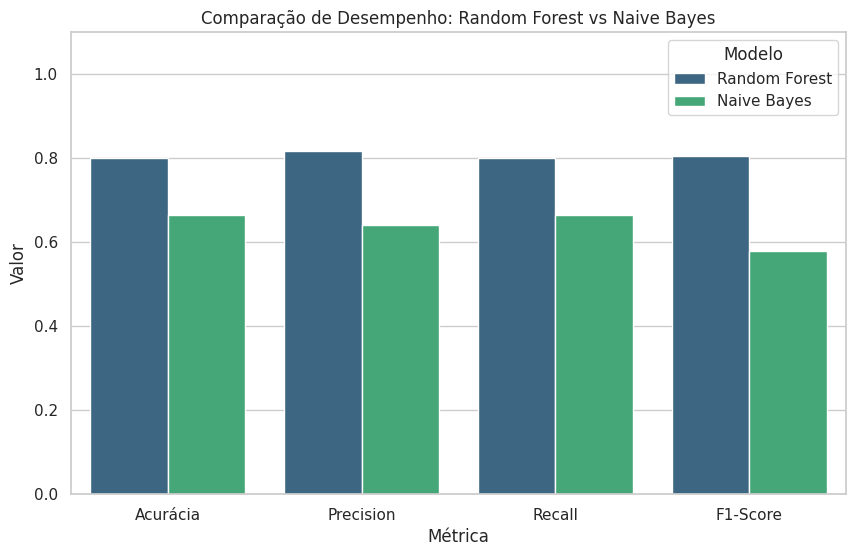

In [ ]:
# ==============================================================================
# CÉLULA 7: COMPARAÇÃO FINAL DOS MODELOS
# ==============================================================================

# Criar DataFrame comparativo
df_compare = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': metrics_rf,
    'Naive Bayes': metrics_nb
})

print("\n--- Comparação Lado a Lado ---")
display(df_compare)

# Gráfico de barras comparativo
df_compare_melted = df_compare.melt(id_vars="Métrica", var_name="Modelo", value_name="Valor")
plt.figure(figsize=(10, 6))
sns.barplot(x="Métrica", y="Valor", hue="Modelo", data=df_compare_melted, palette="viridis")
plt.title("Comparação de Desempenho: Random Forest vs Naive Bayes")
plt.ylim(0, 1.1)
plt.show()

## Comparação de Modelos com Curva ROC (Classificação Binária)

Esta célula avalia e compara o desempenho dos modelos **Random Forest** e **Naive Bayes** utilizando a **Curva ROC** e a métrica **AUC (Area Under the Curve)**. Primeiro, o método `predict_proba()` é usado para obter as probabilidades da **classe positiva (coluna 1)**, pois a curva ROC trabalha com probabilidades e não com rótulos discretos. Em seguida, a função `roc_curve()` calcula a **Taxa de Falsos Positivos (FPR)** e a **Taxa de Verdadeiros Positivos (TPR)** para diferentes limiares de decisão, permitindo construir a curva. A função `roc_auc_score()` mede a **área sob a curva (AUC)**, que resume o desempenho do modelo em um único valor: quanto mais próximo de 1, melhor a capacidade de separar as classes; valores próximos de 0.5 indicam desempenho aleatório. O gráfico final plota as curvas ROC de ambos os modelos, além de uma linha diagonal representando o classificador aleatório como referência. Dessa forma, é possível comparar visualmente e numericamente qual modelo apresenta melhor poder de discriminação, sendo o modelo com **maior AUC e curva mais próxima do canto superior esquerdo** o mais eficiente.


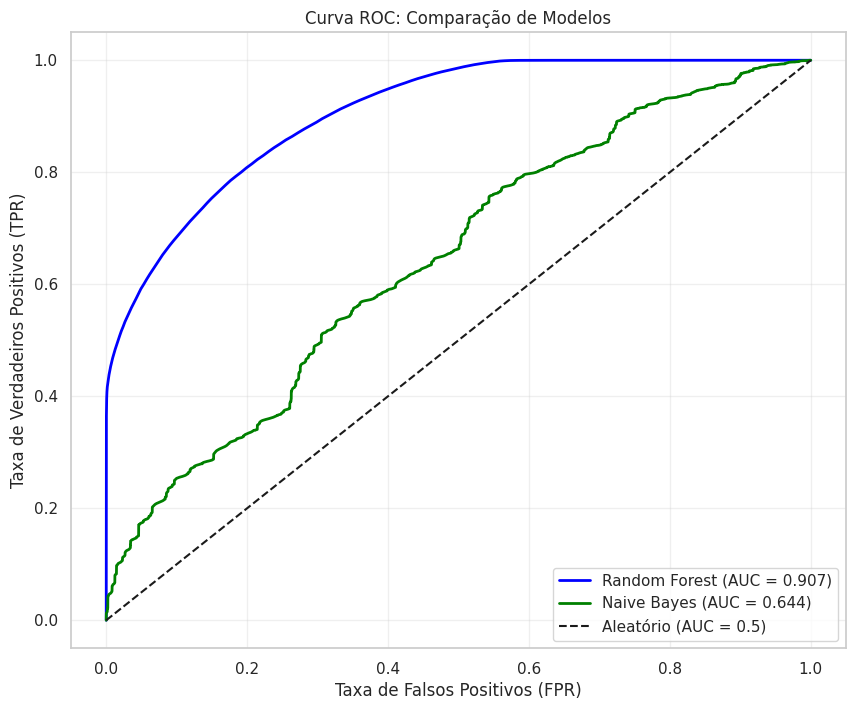

In [ ]:
# ==============================================================================
# NOVA CÉLULA D: COMPARAÇÃO AVANÇADA - CURVA ROC (Versão Binária)
# ==============================================================================
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- Random Forest ---
# Em binário, pegamos a probabilidade da classe positiva (coluna 1)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# --- Naive Bayes ---
y_probs_nb = nb_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
auc_nb = roc_auc_score(y_test, y_probs_nb)

# --- Plotagem ---
plt.figure(figsize=(10, 8))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='blue', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', color='green', linewidth=2)

# Linha base (chute aleatório)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC: Comparação de Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### **CÉLULA 8: IMPORTÂNCIA DAS FEATURES (Apenas Random Forest)**

Os modelos Random Forest têm a capacidade de estimar a importância de cada feature (coluna de entrada) na previsão da variável alvo. Uma feature com alta importância significa que ela contribui significativamente para o poder preditivo do modelo.

Nesta célula, calculamos e visualizamos a importância das features para o modelo Random Forest. Isso nos ajuda a:

*   **Entender o domínio**: Quais fatores são mais relevantes para determinar a aceitação ou bloqueio de um circuito?
*   **Otimização de features**: Se algumas features têm importância muito baixa, elas podem ser removidas para simplificar o modelo sem grande perda de desempenho.
*   **Interpretabilidade**: Ajuda a explicar por que o modelo toma certas decisões.

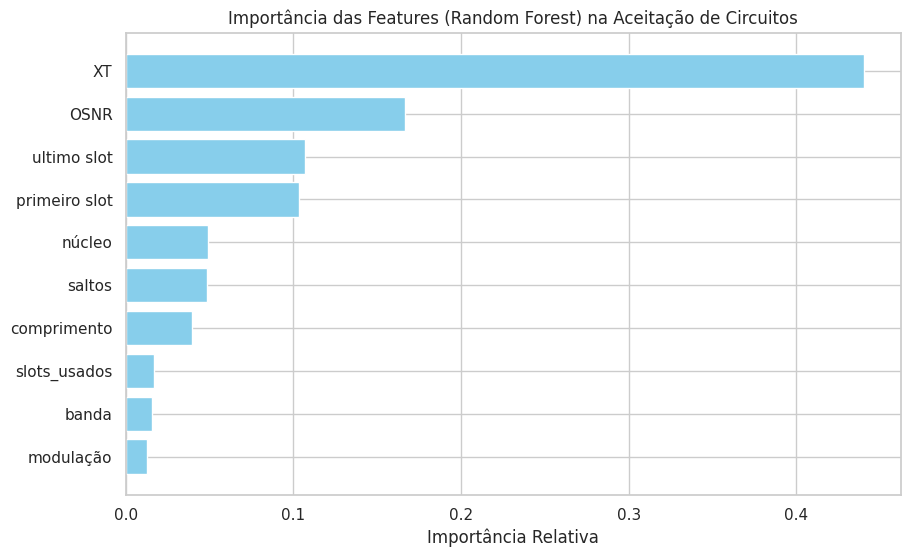

In [ ]:
# ==============================================================================
# CÉLULA 8: IMPORTÂNCIA DAS FEATURES (Apenas Random Forest)
# ==============================================================================

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Importância das Features (Random Forest) na Aceitação de Circuitos")
plt.barh(range(X.shape[1]), importances[indices], align="center", color="skyblue")
plt.yticks(range(X.shape[1]), [features[i] for i in indices])
plt.xlabel("Importância Relativa")
plt.gca().invert_yaxis() # Inverter para a mais importante ficar no topo
plt.show()